In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('NYC EH Data Portal - Asthma emergency department visits due to PM2.5 (filtered).csv')
data

,TimePeriod,GeoTypeDesc,GeoID,GeoRank,BoroID,Borough,Geography,Area,Estimated annual number (under age 18),Estimated annual number (age 18+),"Estimated annual rate (under age 18) per 100,000 children","Estimated annual rate (age 18+) per 100,000 adults"
0,2005-2007,Citywide,1,0,-,-,New York City,New York City,"2,423.9","3,581.3",126.3,56.9
1,2005-2007,Borough,1,1,1,Bronx,Bronx,Bronx,832.4,"1,183.2",212.5,122.3
2,2005-2007,Borough,3,1,3,Manhattan,Manhattan,Manhattan,485.5,797.5,179.4,59.9
3,2005-2007,Borough,2,1,2,Brooklyn,Brooklyn,Brooklyn,642.2,"1,032.4",99.3,55.5
4,2005-2007,Borough,5,1,5,Staten Island,Staten Island,Staten Island,63.1,106.8,55.3,29.6
5,2005-2007,Borough,4,1,4,Queens,Queens,Queens,400.8,461.4,80.8,26.0
6,2005-2007,UHF 42,101,4,1,Bronx,Kingsbridge - Riverdale,Kingsbridge - Riverdale Bronx,15.5,24.9,-,-
7,2005-2007,UHF 42,102,4,1,Bronx,Northeast Bronx,Northeast Bronx Bronx,70.1,97.5,-,-
8,2005-2007,UHF 42,103,4,1,Bronx,Fordham - Bronx Pk,Fordham - Bronx Pk Bronx,126.1,194.2,-,-
9,2005-2007,UHF 42,104,4,1,Bronx,Pelham - Throgs Neck,Pelham - Throgs Neck Bronx,123.4,173.5,-,-


Initial Questions:
- What borough has the most emergency department visits? 
- What age group is the most impacted for asthma due to PM2.5 in 2005 - 2007?

In [10]:
data[data['Borough'].isin([
'Bronx',
'Brooklyn',
'Manhattan',
'Queens',
'Staten Island'
])]

,TimePeriod,GeoTypeDesc,GeoID,GeoRank,BoroID,Borough,Geography,Area,Estimated annual number (under age 18),Estimated annual number (age 18+),"Estimated annual rate (under age 18) per 100,000 children","Estimated annual rate (age 18+) per 100,000 adults"
1,2005-2007,Borough,1,1,1,Bronx,Bronx,Bronx,832.4,"1,183.2",212.5,122.3
2,2005-2007,Borough,3,1,3,Manhattan,Manhattan,Manhattan,485.5,797.5,179.4,59.9
3,2005-2007,Borough,2,1,2,Brooklyn,Brooklyn,Brooklyn,642.2,"1,032.4",99.3,55.5
4,2005-2007,Borough,5,1,5,Staten Island,Staten Island,Staten Island,63.1,106.8,55.3,29.6
5,2005-2007,Borough,4,1,4,Queens,Queens,Queens,400.8,461.4,80.8,26.0
6,2005-2007,UHF 42,101,4,1,Bronx,Kingsbridge - Riverdale,Kingsbridge - Riverdale Bronx,15.5,24.9,-,-
7,2005-2007,UHF 42,102,4,1,Bronx,Northeast Bronx,Northeast Bronx Bronx,70.1,97.5,-,-
8,2005-2007,UHF 42,103,4,1,Bronx,Fordham - Bronx Pk,Fordham - Bronx Pk Bronx,126.1,194.2,-,-
9,2005-2007,UHF 42,104,4,1,Bronx,Pelham - Throgs Neck,Pelham - Throgs Neck Bronx,123.4,173.5,-,-
10,2005-2007,UHF 42,105,4,1,Bronx,Crotona - Tremont,Crotona - Tremont Bronx,177.7,266.0,-,-


In [11]:
filtered_table = data.drop(columns=['GeoTypeDesc','GeoID','GeoRank', 'BoroID', 'Geography', 'Area', 'Estimated annual rate (under age 18) per 100,000 children','Estimated annual rate (age 18+) per 100,000 adults' ])
filtered_table

,TimePeriod,Borough,Estimated annual number (under age 18),Estimated annual number (age 18+)
0,2005-2007,-,"2,423.9","3,581.3"
1,2005-2007,Bronx,832.4,"1,183.2"
2,2005-2007,Manhattan,485.5,797.5
3,2005-2007,Brooklyn,642.2,"1,032.4"
4,2005-2007,Staten Island,63.1,106.8
5,2005-2007,Queens,400.8,461.4
6,2005-2007,Bronx,15.5,24.9
7,2005-2007,Bronx,70.1,97.5
8,2005-2007,Bronx,126.1,194.2
9,2005-2007,Bronx,123.4,173.5


In [12]:
data.groupby('Borough')['Estimated annual number (under age 18)'].sum()

Borough
-                                                          2,423.9
Bronx                       832.415.570.1126.1123.4177.7200.6119.0
Brooklyn         642.222.541.5170.696.515.014.391.145.37.925.01...
Manhattan             485.5111.3149.698.340.714.017.07.02.841.23.6
Queens                400.830.194.225.14.724.011.454.378.434.344.4
Staten Island                                  63.121.924.75.910.6
Name: Estimated annual number (under age 18), dtype: str

In [13]:
filtered_table.dtypes

TimePeriod                                str
Borough                                   str
Estimated annual number (under age 18)    str
Estimated annual number (age 18+)         str
dtype: object

In [14]:
# 1. Select the target columns
cols = ['Estimated annual number (under age 18)', 'Estimated annual number (age 18+)']

# 2. Remove commas, convert to float, and then cast to int
filtered_table[cols] = (
    data[cols]
    .replace({',': ''}, regex=True) # Removes commas
    .astype(float)                 # Converts '2423.9' to 2423.9 (float)
    .astype(int)                   # Truncates decimals to get 2423 (int)
)

filtered_table

,TimePeriod,Borough,Estimated annual number (under age 18),Estimated annual number (age 18+)
0,2005-2007,-,2423,3581
1,2005-2007,Bronx,832,1183
2,2005-2007,Manhattan,485,797
3,2005-2007,Brooklyn,642,1032
4,2005-2007,Staten Island,63,106
5,2005-2007,Queens,400,461
6,2005-2007,Bronx,15,24
7,2005-2007,Bronx,70,97
8,2005-2007,Bronx,126,194
9,2005-2007,Bronx,123,173


In [15]:
# 1. Define the columns you want to sum
cols_to_sum = ['Estimated annual number (under age 18)', 'Estimated annual number (age 18+)']

# 2. Group by the Borough column and calculate the sum
borough_totals = filtered_table.groupby('Borough')[cols_to_sum].sum()

# 3. View the results
print(borough_totals)


               Estimated annual number (under age 18)  \
Borough                                                 
-                                                2423   
Bronx                                            1662   
Brooklyn                                         1280   
Manhattan                                         967   
Queens                                            798   
Staten Island                                     123   

               Estimated annual number (age 18+)  
Borough                                           
-                                           3581  
Bronx                                       2363  
Brooklyn                                    2058  
Manhattan                                   1590  
Queens                                       918  
Staten Island                                211  


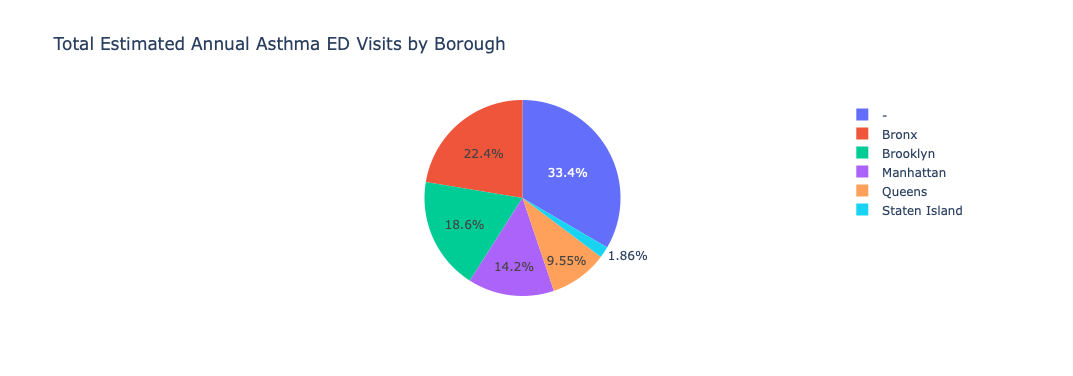

In [17]:
import plotly.express as px

# 1. Reset the index so 'Borough' becomes a normal column
df_plot = borough_totals.reset_index()

# 2. Add the two age columns together to use as the chart values
fig = px.pie(
    df_plot,
    values=df_plot['Estimated annual number (under age 18)'] + df_plot['Estimated annual number (age 18+)'],
    names='Borough',
    title='Total Estimated Annual Asthma ED Visits by Borough'
)

# 3. Show the chart
fig.show()
